In [ ]:

# =========================
# Part I: Data Extraction
# =========================

import pandas as pd

#  reload raw file
df = pd.read_csv("./output/jpm_retail_portfolio_raw.csv")

#  pivot to wide format
df_wide = df.pivot(index="Quarter", columns="Metric", values="Value").reset_index()

In [ ]:

# =========================
# Part II : Data Preparation
# =========================

# rename PPNR column
df_wide = df_wide.rename(columns={"Pre-provision profit": "PPNR"})

# convert quarter to time
df_wide["Year"] = df_wide["Quarter"].str[-2:].astype(int) + 2000
df_wide["Q"] = df_wide["Quarter"].str[0].astype(int)

# create quarterly date
df_wide["date"] = pd.PeriodIndex(
    year=df_wide["Year"],
    quarter=df_wide["Q"],
    freq="Q"
).to_timestamp()

# sort by date
df_wide = df_wide.sort_values("date").reset_index(drop=True)

# create lagged PPNR
df_wide["PPNR_lag1"] = df_wide["PPNR"].shift(1)
df_wide["PPNR_lag2"] = df_wide["PPNR"].shift(2)

# only drop rows missing these fields
df_model = df_wide.dropna(subset=["PPNR", "PPNR_lag1", "PPNR_lag2"]).copy()

# remove column index names
df_model.columns.name = None
df_wide.columns.name = None

# convert numeric columns
non_numeric_cols = ["Quarter", "Year", "Q", "date"]

for col in df_model.columns:
    if col not in non_numeric_cols:
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# check result for initial variables
print(df_wide.shape)
print(df_model.shape)
print(
    df_model[
        [
            "Quarter", "PPNR", "PPNR_lag1", "PPNR_lag2",
            "Loans", "Deposits", "Total assets",
            "Nonperforming assets", "Net charge-offs"
        ]
    ].head()
)

(63, 29)
(56, 29)
  Quarter     PPNR  PPNR_lag1  PPNR_lag2     Loans  Deposits  Total assets  \
2    3Q09  13167.0    12103.0    11652.0  653144.0  867977.0     2041009.0   
3    4Q09  11160.0    13167.0    12103.0  633458.0  938367.0     2031989.0   
4    1Q10  11547.0    11160.0    13167.0  713799.0  925303.0     2135796.0   
5    2Q10  10470.0    11547.0    11160.0  699483.0  887805.0     2014019.0   
6    3Q10   9426.0    10470.0    11547.0  690531.0  903138.0     2141595.0   

   Nonperforming assets  Net charge-offs  
2               20362.0           6373.0  
3               19741.0           6177.0  
4               19019.0           7910.0  
5               18156.0           5714.0  
6               17656.0           4945.0  


In [11]:
# remove the pivot column label
df_model.columns.name = None

# make sure all model variables except identifiers are numeric
non_numeric_cols = ["Quarter", "Year", "Q", "date"]

for col in df_model.columns:
    if col not in non_numeric_cols:
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# check whether PPNR is numeric
print(df_model["PPNR"].dtype)

# build correlation matrix first
corr_matrix = df_model.drop(columns=["Year", "Q"]).corr(numeric_only=True)

# then get correlation with PPNR
corr_with_ppnr = corr_matrix["PPNR"].sort_values(ascending=False)
print(corr_with_ppnr)

float64
PPNR                                                 1.000000
Total net revenue                                    0.968964
Common stockholders’ equity                          0.893840
Income before income tax expense                     0.887747
Long-term debt                                       0.875465
PPNR_lag1                                            0.867921
Loans                                                0.853883
Common equity Tier 1 (“CET1”) capital ratio          0.851409
Net income                                           0.849574
Total noninterest expense                            0.825118
Total assets                                         0.816575
Total capital ratio                                  0.802105
PPNR_lag2                                            0.789978
Tier 1 capital ratio                                 0.768999
Consumer net charge-off rate                         0.753160
Deposits                                             0.741982


In [12]:
model_vars = [
    "date",   
    "PPNR",
    "PPNR_lag1",
    "PPNR_lag2",
    "Total assets",
    "Nonperforming assets",
    "Net charge-offs"
]

df_reg = df_model[model_vars].dropna().copy()

print(df_reg.head())

        date     PPNR  PPNR_lag1  PPNR_lag2  Total assets  \
2 2009-07-01  13167.0    12103.0    11652.0     2041009.0   
3 2009-10-01  11160.0    13167.0    12103.0     2031989.0   
4 2010-01-01  11547.0    11160.0    13167.0     2135796.0   
5 2010-04-01  10470.0    11547.0    11160.0     2014019.0   
6 2010-07-01   9426.0    10470.0    11547.0     2141595.0   

   Nonperforming assets  Net charge-offs  
2               20362.0           6373.0  
3               19741.0           6177.0  
4               19019.0           7910.0  
5               18156.0           5714.0  
6               17656.0           4945.0  


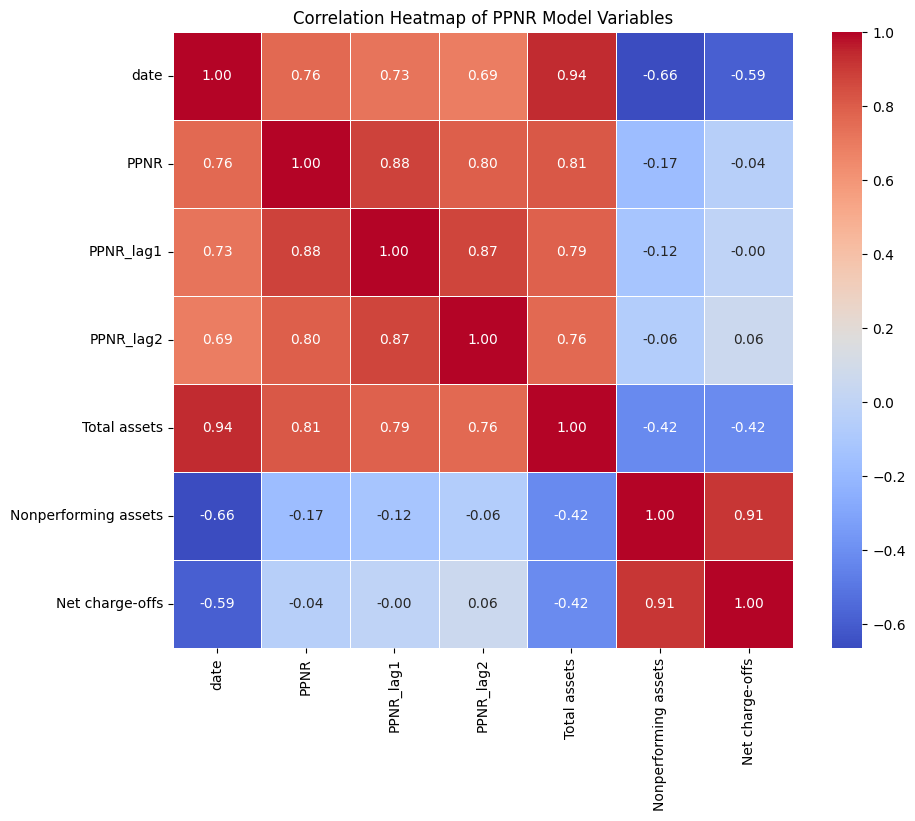

In [13]:
# Init. heatmap
# checking corr for the variables

import seaborn as sns
import matplotlib.pyplot as plt

corr = df_reg.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, 
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            linewidths=0.5)

plt.title("Correlation Heatmap of PPNR Model Variables")
plt.show()

In [14]:
# Add macro data

# load macro data
macro = pd.read_csv("./output/ccar_macro_data_quarterly.csv")

# convert date
macro["DATE"] = pd.to_datetime(macro["DATE"])

# make df_reg date match
df_reg["DATE"] = pd.to_datetime(df_reg["date"]) + pd.offsets.QuarterEnd(0)

# merge
df_merged = pd.merge(df_reg, macro, on="DATE", how="inner")
df_merged = df_merged.sort_values("DATE")

print(df_merged[["DATE"]].head())
print(df_merged.shape)


        DATE
0 2009-09-30
1 2009-12-31
2 2010-03-31
3 2010-06-30
4 2010-09-30
(49, 45)


In [ ]:

# =========================
# Part III : Init. Model
# =========================

# Init OLS model

import statsmodels.api as sm

y = df_reg["PPNR"]

X = df_reg[
    [
    "PPNR_lag1",
    "PPNR_lag2",
    #"Loans",
    #"Deposits",
    "Total assets",
    "Nonperforming assets",
    "Net charge-offs"
    ]
]

# intercept
X = sm.add_constant(X)

# run OLS regression
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   PPNR   R-squared:                       0.853
Model:                            OLS   Adj. R-squared:                  0.836
Method:                 Least Squares   F-statistic:                     50.02
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           7.80e-17
Time:                        23:11:29   Log-Likelihood:                -434.00
No. Observations:                  49   AIC:                             880.0
Df Residuals:                      43   BIC:                             891.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                -1384.4686 

In [16]:
# Init. VIF 

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# predictors only (remove constant if present)
X_vif = df_reg[
    [
    "PPNR_lag1",
    "PPNR_lag2",
    #"Loans",
    #"Deposits",
    "Total assets",
    "Nonperforming assets",
    "Net charge-offs"
    ]
]


X_vif = sm.add_constant(X_vif)

vif = pd.DataFrame()
vif["Variable"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# remove constant row
vif = vif[vif["Variable"] != "const"]

# sort by VIF descending
vif = vif.sort_values(by="VIF", ascending=False)

print(vif)

               Variable        VIF
5       Net charge-offs  10.919954
4  Nonperforming assets   7.496440
3          Total assets   7.199626
2             PPNR_lag2   5.690748
1             PPNR_lag1   5.617277


In [17]:
# Checking for final

# Final varibales

df_final_vars = df_merged[
    [
        "PPNR",
        "PPNR_lag1",
        "Total assets",
        "10Y_Treasury_Yield"
    ]
].head(10)  # show first 10 rows like your example

df_final_vars

,PPNR,PPNR_lag1,Total assets,10Y_Treasury_Yield
0,13167.0,12103.0,2041009.0,3.517812
1,11160.0,13167.0,2031989.0,3.464032
2,11547.0,11160.0,2135796.0,3.717869
3,10470.0,11547.0,2014019.0,3.492500
4,9426.0,10470.0,2141595.0,2.784531
5,10055.0,9426.0,2117605.0,2.878387
6,9226.0,10055.0,2198161.0,3.457419
7,9937.0,9226.0,2246764.0,3.201429
8,8229.0,9937.0,2289240.0,2.414219
9,6931.0,8229.0,2265792.0,2.046721


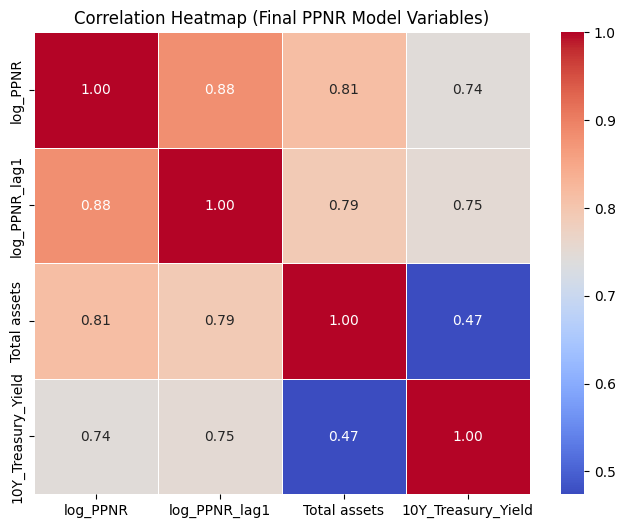

In [21]:
# Final Heatmap

import numpy as np

df_merged["log_PPNR"] = np.log(df_merged["PPNR"])
df_merged["log_PPNR_lag1"] = np.log(df_merged["PPNR_lag1"])

# select final variables
df_final = df_merged[
    [
        "log_PPNR",
        "log_PPNR_lag1",
        "Total assets",
        "10Y_Treasury_Yield"
    ]
]

# correlation matrix
corr_final = df_final.corr()

# plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_final,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap (Final PPNR Model Variables)")
plt.show()


In [ ]:

# =========================
# Part IV : Final Model 
# =========================


# final OLS model
import numpy as np
import statsmodels.api as sm

# log transform
df_merged["log_PPNR"] = np.log(df_merged["PPNR"])
df_merged["log_PPNR_lag1"] = np.log(df_merged["PPNR_lag1"])


X = df_merged[
    [
        "log_PPNR_lag1",
        "Total assets",
        "10Y_Treasury_Yield"
    ]
].copy()

# scale assets
X.loc[:, "Total assets"] = X["Total assets"] / 1e6

X = sm.add_constant(X)
y = df_merged["log_PPNR"]

model_log = sm.OLS(y, X).fit()
print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:               log_PPNR   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.839
Method:                 Least Squares   F-statistic:                     84.49
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           1.64e-18
Time:                        23:13:22   Log-Likelihood:                 32.240
No. Observations:                  49   AIC:                            -56.48
Df Residuals:                      45   BIC:                            -48.91
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  5.2897      1

In [23]:
# Final VIF

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import statsmodels.api as sm

X_vif = df_merged[
    [
        "log_PPNR_lag1",
        "Total assets",
        "10Y_Treasury_Yield"
    ]
].copy()

# apply same scaling as model
X_vif.loc[:, "Total assets"] = X_vif["Total assets"] / 1e6

# add constant
X_vif = sm.add_constant(X_vif)

# compute VIF
vif = pd.DataFrame()
vif["Variable"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# remove constant
vif = vif[vif["Variable"] != "const"]

# sort
vif = vif.sort_values(by="VIF", ascending=False)

print(vif)

             Variable       VIF
1       log_PPNR_lag1  5.190556
2        Total assets  2.931631
3  10Y_Treasury_Yield  2.501638


In [ ]:

# =========================
# Part V : Model diagnostics
# =========================

# check residual behavior
residuals = model_log.resid
fitted = model_log.fittedvalues

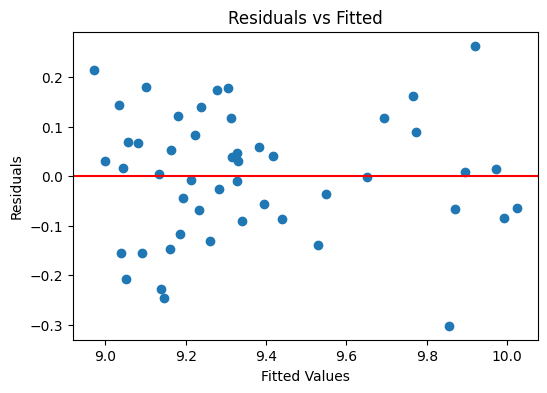

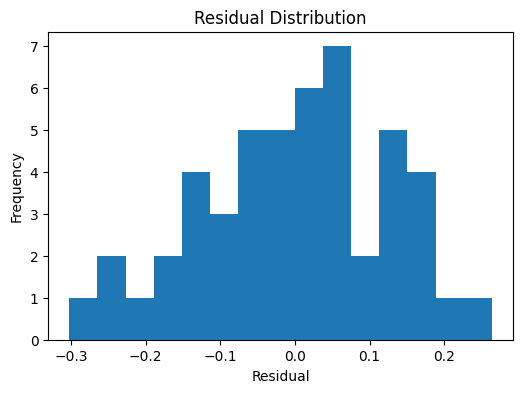

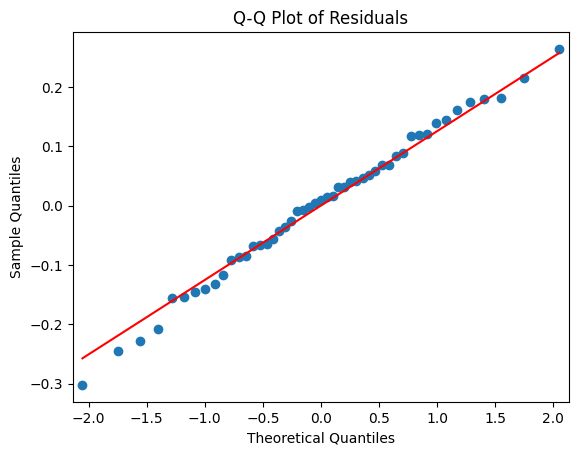

In [25]:
import matplotlib.pyplot as plt

# residual vs. fitted plot

plt.figure(figsize=(6,4))
plt.scatter(fitted, residuals)
plt.axhline(0, color='red')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()


# residual distribution
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=15)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()


# Q-Q plot
import statsmodels.api as sm

sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot of Residuals")
plt.show()

In [26]:
# identify which quater for the outlier

# get absolute residuals
abs_res = residuals.abs()

# get top 2 largest
top2_idx = abs_res.nlargest(2).index

pd.DataFrame({
    "Quarter": df_model["Quarter"],
    "Actual_PPNR": y,
    "Predicted_PPNR": model_log.fittedvalues,
    "Residual": residuals
}).loc[top2_idx]

,Quarter,Actual_PPNR,Predicted_PPNR,Residual
42,2Q20,9.553079,9.855277,-0.302198
44,4Q20,10.184409,9.920383,0.264026


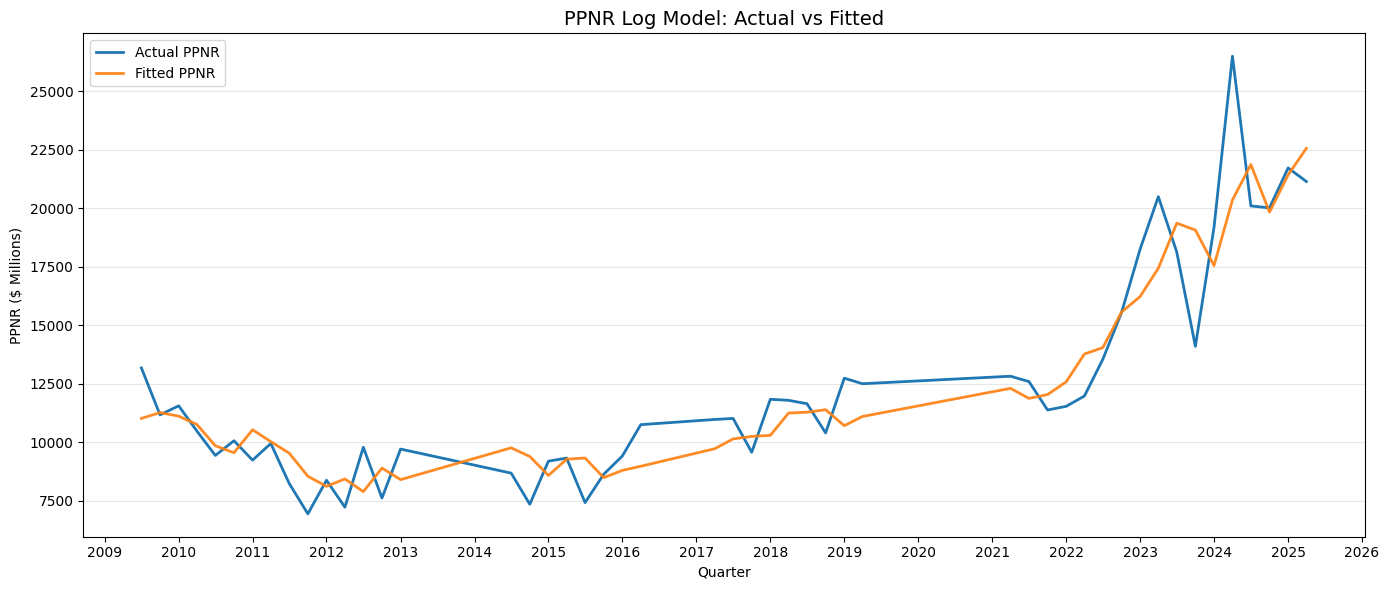

In [60]:

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =========================
# Visualization for log model
# In-sample predictions use actual lagged PPNR
# =========================

df_merged["Pred_log"] = model_log.fittedvalues
df_merged["Pred_level"] = np.exp(df_merged["Pred_log"])
df_merged["Pred_smooth"] = df_merged["Pred_level"].rolling(window=3, center=True).mean()

plt.figure(figsize=(14, 6))

# actual
plt.plot(
    df_merged["date"],
    df_merged["PPNR"],
    label="Actual PPNR",
    linewidth=2
)

# fitted
plt.plot(
    df_merged["date"],
    df_merged["Pred_level"],
    label="Fitted PPNR",
    linewidth=2,
    alpha=0.9
)


plt.title("PPNR Log Model: Actual vs Fitted", fontsize=14)
plt.xlabel("Quarter")
plt.ylabel("PPNR ($ Millions)")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.legend(frameon=True)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
# =========================
# Part VI: PPNR Forecast
# =========================

import pandas as pd
import numpy as np

# ---------------------------------
# 1. Load scenario data
# ---------------------------------
scenario = pd.read_csv("./raw_data/Severely Adverse Scenario Data.csv").copy()

# check for asset
last_assets = df_merged["Total assets"].iloc[-1]
print(last_assets)

scenario["Date"] = scenario["Date"].astype(str).str.replace(" ", "", regex=False)
scenario["Date"] = pd.PeriodIndex(scenario["Date"], freq="Q")
scenario["Total assets"] = last_assets

# ---------------------------------
# 2. Rename scenario columns
#    Adjust these names to match your model variables
# ---------------------------------
scenario = scenario.rename(columns={
    "10-year Treasury yield": "10Y_Treasury_Yield"
})

print(scenario.head())
print(scenario.columns)

4552482.0
     Date  Real GDP growth  Nominal GDP growth  Real disposable income growth  \
0  2000Q1              1.5                 4.2                            7.2   
1  2000Q2              7.5                10.2                            4.8   
2  2000Q3              0.4                 2.8                            5.4   
3  2000Q4              2.4                 4.6                            2.7   
4  2001Q1             -1.3                 1.3                            3.2   

   Nominal disposable income growth  Unemployment rate  CPI inflation rate  \
0                              10.7                4.0                 4.0   
1                               6.8                3.9                 3.2   
2                               8.1                4.0                 3.7   
3                               5.1                3.9                 2.9   
4                               6.3                4.2                 3.9   

   3-month Treasury rate  5-year T

In [39]:
scenario["Total assets"] = scenario["Total assets"] / 1e6
print(scenario[["Date", "Total assets", "10Y_Treasury_Yield"]].head())

     Date  Total assets  10Y_Treasury_Yield
0  2000Q1      4.552482                 6.7
1  2000Q2      4.552482                 6.4
2  2000Q3      4.552482                 6.1
3  2000Q4      4.552482                 5.8
4  2001Q1      4.552482                 5.3


In [52]:
# Forecast 2026Q1 to 2029Q1 recursively

last_log_ppnr = df_merged["log_PPNR"].iloc[-1]
print("\nLast Log PPNR:")
print(last_log_ppnr)

proj = scenario.loc[
    (scenario["Date"] >= pd.Period("2026Q1", freq="Q")) &
    (scenario["Date"] <= pd.Period("2029Q1", freq="Q"))
].copy()

print("\nForecast PPNR path:")
print(proj[["Date", "Total assets", "10Y_Treasury_Yield"]])
print(len(proj))


Last Log PPNR:
9.958591078762153

Forecast PPNR path:
       Date  Total assets  10Y_Treasury_Yield
104  2026Q1      4.552482                 3.1
105  2026Q2      4.552482                 2.7
106  2026Q3      4.552482                 2.4
107  2026Q4      4.552482                 2.3
108  2027Q1      4.552482                 2.3
109  2027Q2      4.552482                 2.3
110  2027Q3      4.552482                 2.4
111  2027Q4      4.552482                 2.4
112  2028Q1      4.552482                 2.4
113  2028Q2      4.552482                 2.5
114  2028Q3      4.552482                 2.5
115  2028Q4      4.552482                 2.6
116  2029Q1      4.552482                 2.7
13


In [ ]:
# Forecast loop

preds = []

prev_log_ppnr = last_log_ppnr

for _, row in proj.iterrows():
    q = row["Date"]

    log_ppnr_hat = (
        model_log.params["const"]
        + model_log.params["log_PPNR_lag1"] * prev_log_ppnr
        + model_log.params["Total assets"] * row["Total assets"]
        + model_log.params["10Y_Treasury_Yield"] * row["10Y_Treasury_Yield"]
    )

    ppnr_hat = np.exp(log_ppnr_hat)

    preds.append({
        "Quarter": q,
        "log_PPNR_lag1_used": prev_log_ppnr,
        "10Y_Treasury_Yield": row["10Y_Treasury_Yield"],
        "Total assets": row["Total assets"],
        "Pred_log_PPNR": log_ppnr_hat,
        "Pred_PPNR": ppnr_hat
    })

    # recursive update
    prev_log_ppnr = log_ppnr_hat

forecast_ppnr = pd.DataFrame(preds)

print(forecast_ppnr)

   Quarter  log_PPNR_lag1_used  10Y_Treasury_Yield  Total assets  \
0   2026Q1            9.958591                 3.1      4.552482   
1   2026Q2            9.879672                 2.7      4.552482   
2   2026Q3            9.809385                 2.4      4.552482   
3   2026Q4            9.752774                 2.3      4.552482   
4   2027Q1            9.722259                 2.3      4.552482   
5   2027Q2            9.711550                 2.3      4.552482   
6   2027Q3            9.707792                 2.4      4.552482   
7   2027Q4            9.717122                 2.4      4.552482   
8   2028Q1            9.720396                 2.4      4.552482   
9   2028Q2            9.721545                 2.5      4.552482   
10  2028Q3            9.732596                 2.5      4.552482   
11  2028Q4            9.736474                 2.6      4.552482   
12  2029Q1            9.748484                 2.7      4.552482   

    Pred_log_PPNR     Pred_PPNR  
0        9.87

         Date Quarter     PPNR
48 2025-04-01  2025Q2  21133.0


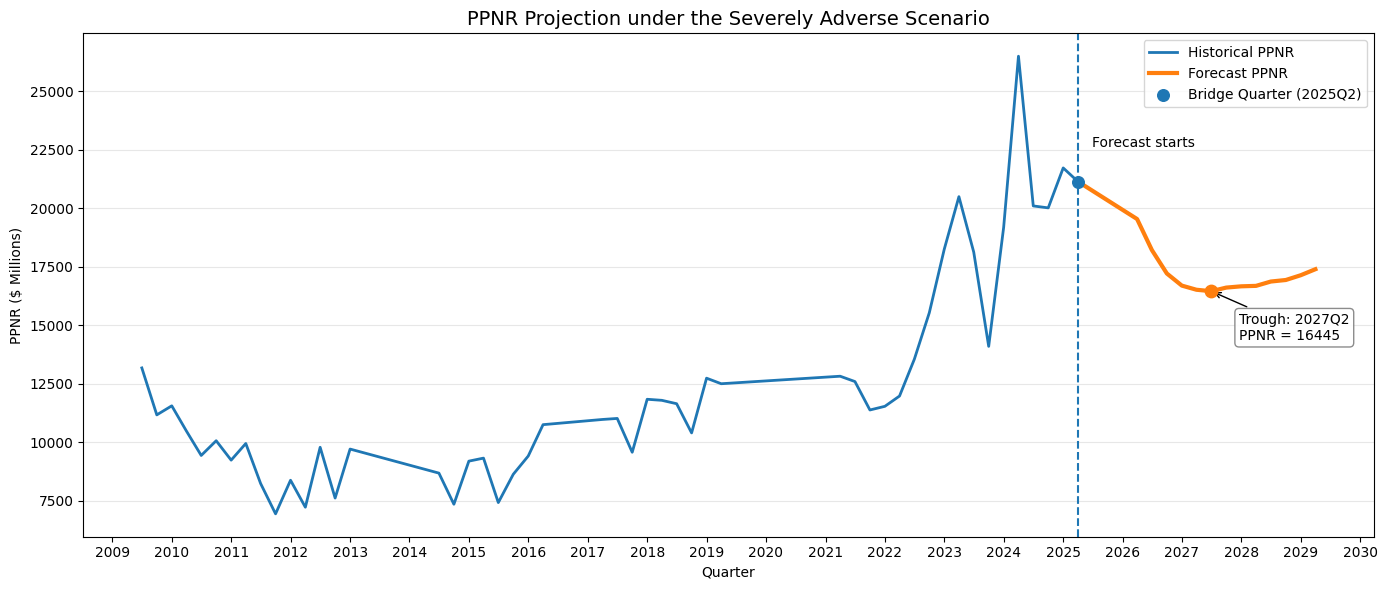

In [ ]:
# Visualization for forecasting
# forecast uses recursively predicted values

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =========================
# Historical + Forecast PPNR plot
# =========================

# historical data
hist = df_merged[["date", "PPNR"]].copy()
hist["Quarter"] = hist["date"].dt.to_period("Q").astype(str)

# bridge quarter = last actual quarter (2025Q4)
bridge_df = hist[["date", "Quarter", "PPNR"]].tail(1).copy()
bridge_df = bridge_df.rename(columns={"date": "Date"})
print(bridge_df)

# forecast path
fcst_plot = forecast_ppnr.copy()
fcst_plot["Quarter"] = fcst_plot["Quarter"].astype(str)
fcst_plot["Date"] = fcst_plot["Quarter"].str.replace("Q1", "-03-31") \
                                      .str.replace("Q2", "-06-30") \
                                      .str.replace("Q3", "-09-30") \
                                      .str.replace("Q4", "-12-31")
fcst_plot["Date"] = pd.to_datetime(fcst_plot["Date"])
fcst_plot = fcst_plot.rename(columns={"Pred_PPNR": "PPNR"})

# split actual vs forecast
actual_cutoff = bridge_df["Date"].iloc[0]
forecast_start = bridge_df["Date"].iloc[0]

actual_part = hist[hist["date"] <= actual_cutoff].copy()
actual_part = actual_part.rename(columns={"date": "Date"})

forecast_part = pd.concat(
    [bridge_df[["Date", "Quarter", "PPNR"]], fcst_plot[["Date", "Quarter", "PPNR"]]],
    ignore_index=True
)

# trough forecast point (more meaningful for adverse PPNR)
trough_idx = forecast_part["PPNR"].idxmin()
trough_row = forecast_part.loc[trough_idx]

# plot
plt.figure(figsize=(14, 6))

# historical actual
plt.plot(
    actual_part["Date"],
    actual_part["PPNR"],
    label="Historical PPNR",
    linewidth=2
)

# forecast path
plt.plot(
    forecast_part["Date"],
    forecast_part["PPNR"],
    label="Forecast PPNR",
    linewidth=3
)

# bridge point
plt.scatter(
    bridge_df["Date"],
    bridge_df["PPNR"],
    s=70,
    zorder=5,
    label=f"Bridge Quarter ({bridge_df['Quarter'].iloc[0]})"
)

# forecast start line
plt.axvline(
    x=forecast_start,
    linestyle="--",
    linewidth=1.5
)

# annotate trough
plt.scatter(
    trough_row["Date"],
    trough_row["PPNR"],
    s=80,
    zorder=6
)

plt.annotate(
    f"Trough: {trough_row['Quarter']}\nPPNR = {trough_row['PPNR']:.0f}",
    xy=(trough_row["Date"], trough_row["PPNR"]),
    xytext=(20, -35),
    textcoords="offset points",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),
    arrowprops=dict(arrowstyle="->", lw=1)
)

# annotate forecast start
plt.annotate(
    "Forecast starts",
    xy=(forecast_start, bridge_df["PPNR"].iloc[0]),
    xytext=(10, 25),
    textcoords="offset points",
    fontsize=10
)

# formatting
plt.title("PPNR Projection under the Severely Adverse Scenario", fontsize=14)
plt.xlabel("Quarter")
plt.ylabel("PPNR ($ Millions)")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.legend(frameon=True)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()